In [134]:
# https://platform.olimpiada-ai.ro/en/problems/206

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [135]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/bank-marketing/train.csv")
test = pd.read_csv("/kaggle/input/datasets/abukanabek/bank-marketing/test.csv")
subm = pd.read_csv("/kaggle/input/datasets/abukanabek/bank-marketing/sample_output.csv")

In [136]:
train.shape, test.shape, subm.shape

((8929, 18), (2233, 17), (4468, 3))

In [137]:
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,6456,33,admin.,married,secondary,no,2,yes,no,unknown,20,may,201,1,-1,0,unknown,0
1,5432,35,technician,married,secondary,no,545,yes,no,cellular,16,apr,1579,1,234,4,failure,1
2,6372,39,management,married,tertiary,no,763,yes,no,cellular,11,may,877,7,300,2,other,1
3,2254,37,management,married,tertiary,no,5106,no,no,cellular,30,apr,244,1,-1,0,unknown,1
4,8350,30,unemployed,married,tertiary,no,330,no,no,cellular,14,apr,111,1,-1,0,unknown,1


In [138]:
subtask1 = train.groupby('job')['deposit'].mean().sort_values(ascending=False).index[0]
subtask2 = train[train['contact']=='telephone']['month'].value_counts().sort_values(ascending=False).index[1]
subtask1, subtask2

('student', 'may')

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = test.select_dtypes('number').drop(columns='id').columns

train[numeric_features] = scaler.fit_transform(train[numeric_features])
test[numeric_features] = scaler.transform(test[numeric_features])

In [140]:
from sklearn.model_selection import train_test_split
from catboost import Pool

features = [c for c in train.columns if c not in ['id', 'deposit']]
cat_features = [c for c in train.select_dtypes('object').columns if c in features]
target_col = 'deposit'

X, y = train[features], train[target_col]
X_test = test[features]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_features)

In [141]:
from catboost import CatBoostClassifier

params = {
    'iterations': 2000,
    'loss_function': 'Logloss',
    'eval_metric': 'TotalF1:average=Macro',
    'metric_period': 200,
    'max_depth': 3,
    'random_state': 42,
    'learning_rate': 0.1
}

model = CatBoostClassifier(**params)

model.fit(train_pool, eval_set=valid_pool)

0:	learn: 0.7618193	test: 0.7590724	best: 0.7590724 (0)	total: 6.24ms	remaining: 12.5s
200:	learn: 0.8648670	test: 0.8361937	best: 0.8361937 (200)	total: 907ms	remaining: 8.12s
400:	learn: 0.8785758	test: 0.8419269	best: 0.8419269 (400)	total: 1.86s	remaining: 7.41s
600:	learn: 0.8818170	test: 0.8430596	best: 0.8430596 (600)	total: 2.84s	remaining: 6.6s
800:	learn: 0.8875487	test: 0.8453016	best: 0.8453016 (800)	total: 3.81s	remaining: 5.71s
1000:	learn: 0.8936456	test: 0.8475436	best: 0.8475436 (1000)	total: 4.82s	remaining: 4.81s
1200:	learn: 0.8993729	test: 0.8464914	best: 0.8475436 (1000)	total: 5.84s	remaining: 3.88s
1400:	learn: 0.9033526	test: 0.8487324	best: 0.8487324 (1400)	total: 6.84s	remaining: 2.92s
1600:	learn: 0.9069511	test: 0.8487483	best: 0.8487483 (1600)	total: 7.87s	remaining: 1.96s
1800:	learn: 0.9106823	test: 0.8521019	best: 0.8521019 (1800)	total: 8.93s	remaining: 987ms
1999:	learn: 0.9142885	test: 0.8476201	best: 0.8521019 (1800)	total: 9.97s	remaining: 0us

bes

CatBoostClassifier(eval_metric='TotalF1:average=Macro', iterations=2000, learning_rate=0.1, loss_function='Logloss', max_depth=3, metric_period=200, random_state=42)

In [142]:
subtask3 = model.predict(X_test).tolist()

In [143]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

test_pca = pca.fit_transform(test[numeric_features])

test_pca.shape, pca.explained_variance_ratio_.sum()

((2233, 2), np.float64(0.4060321293672528))

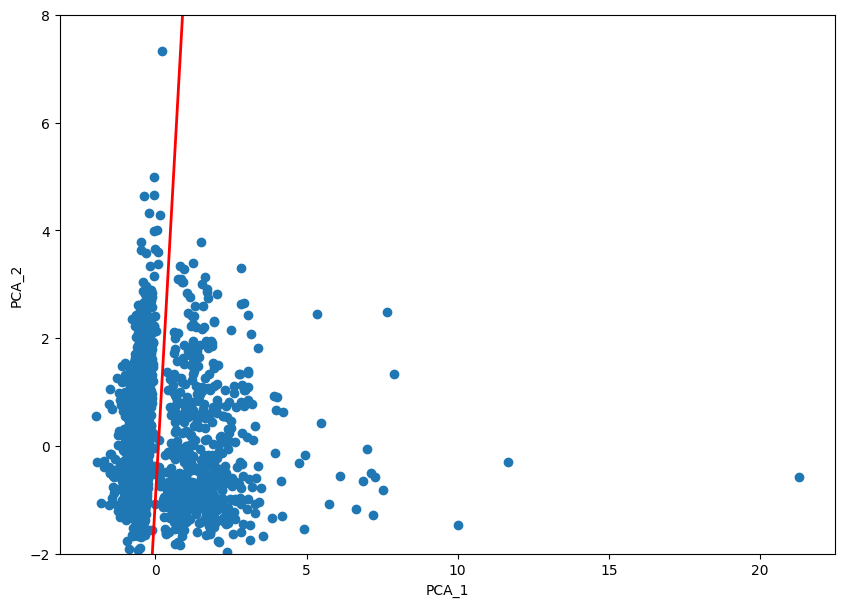

In [144]:
plt.figure(figsize=(10, 7))

plt.scatter(test_pca[:, 0], test_pca[:, 1])
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')

k, b = 10, -1
xs = np.linspace(-2, 1, 100)
ys = xs * k + b
plt.plot(xs, ys, color='red', linewidth=2)
plt.ylim(-2, 8)
plt.show()

In [145]:
clusters = (test_pca[:, 0] * k + b > test_pca[:, 1]).astype(int)
clusters

array([0, 0, 0, ..., 0, 0, 1])

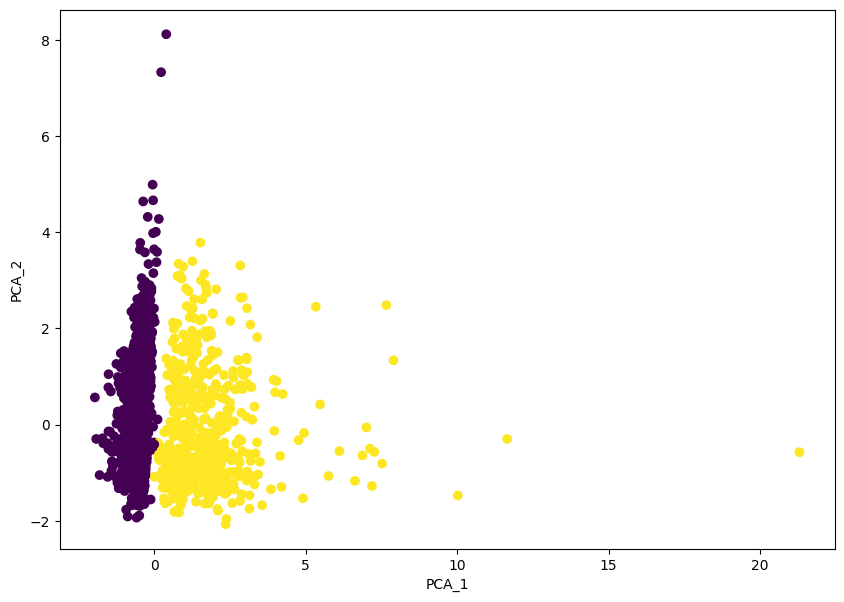

In [146]:
plt.figure(figsize=(10, 7))

plt.scatter(test_pca[:, 0], test_pca[:, 1], c=clusters)
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')

plt.show()

In [147]:
subm = pd.DataFrame({
    'subtaskID': [1, 2] + [3] * len(test) + [4] * len(test),
    'datapointID': [1, 1] + test['id'].tolist()*2,
    'answer': [subtask1, subtask2] + subtask3 + clusters.tolist()
})

subm.to_csv("submission.csv", index=False)

subm.head()

,subtaskID,datapointID,answer
0,1,1,student
1,2,1,may
2,3,5686,0
3,3,5206,1
4,3,5160,0
